# Paper figures

Here we reproduce the figures in the order they appear in the paper.

In [1]:
# Import libraries

from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.utils import *

import matplotlib.pyplot as plt
import librosa
from scipy.signal.windows import hann

from time import time

## Fig. 1 - Effects of window length on the spectrogram

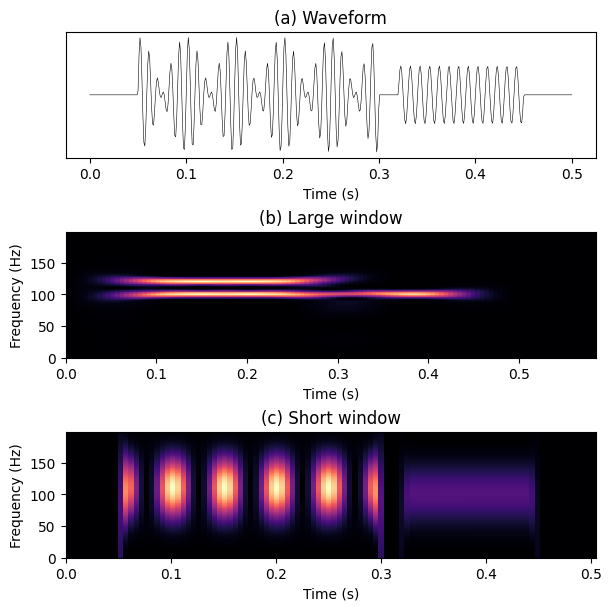

In [2]:
sr = 1000 # sample rate
t, signal = generate_toy_signal(sr)

axes = new_axes(3, 1, figsize=[6, 6]) # 3 row, 1 cols

plot_signal(signal, times=t, ax=axes[0], title='(a) Waveform')

X1 = Spectrogram(signal, sr=sr, window_size_s=180e-3, hop_size_s=5e-3, nfft=1024)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3, hop_size_s=5e-3, nfft=1024)

x1 = X1.power_spectrogram()
x2 = X2.power_spectrogram()

display_spectrogram(x1, ax=axes[1], f_bins=X1.f_bins, t_frames=X1.t_frames, high_f=200, title='(b) Large window') # in paper we remove last frames of x1 for readability
display_spectrogram(x2, ax=axes[2], f_bins=X2.f_bins, t_frames=X2.t_frames, high_f=200, title='(c) Short window')

## Fig. 2 - Time-frequency grids used for OT

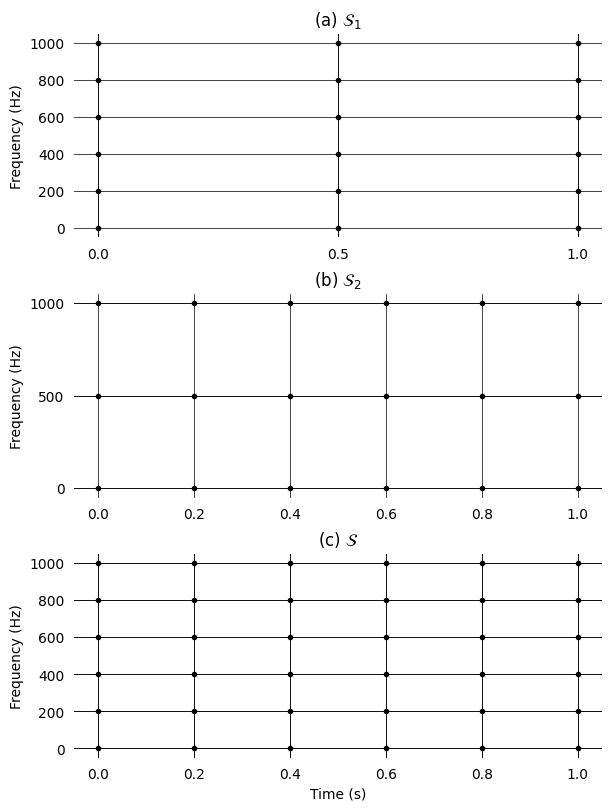

In [3]:
f_bins_1   = np.linspace(0, 1000, 6) # 6 bins from 0 to 1kHz
f_bins_2   = np.linspace(0, 1000, 3) # 3 bins from 0 to 1kHz

t_frames_1 = np.linspace(0, 1, 3) # 3 frames from 0 to 1 second
t_frames_2 = np.linspace(0, 1, 6) # 6 frames from 0 to 1 second

S1 = time_freq_support(f_bins_1, t_frames_1)
S2 = time_freq_support(f_bins_2, t_frames_2)
S  = time_freq_support(f_bins_1, t_frames_2)

axes = new_axes(3, 1, figsize=[6, 8])

display_support(S1, ax=axes[0], title=r'(a) $\mathcal{S}_1$', xlabel='')
display_support(S2, ax=axes[1], title=r'(b) $\mathcal{S}_2$', xlabel='')
display_support(S , ax=axes[2], title=r'(c) $\mathcal{S}$')

## Fig. 3 - Cost matrices

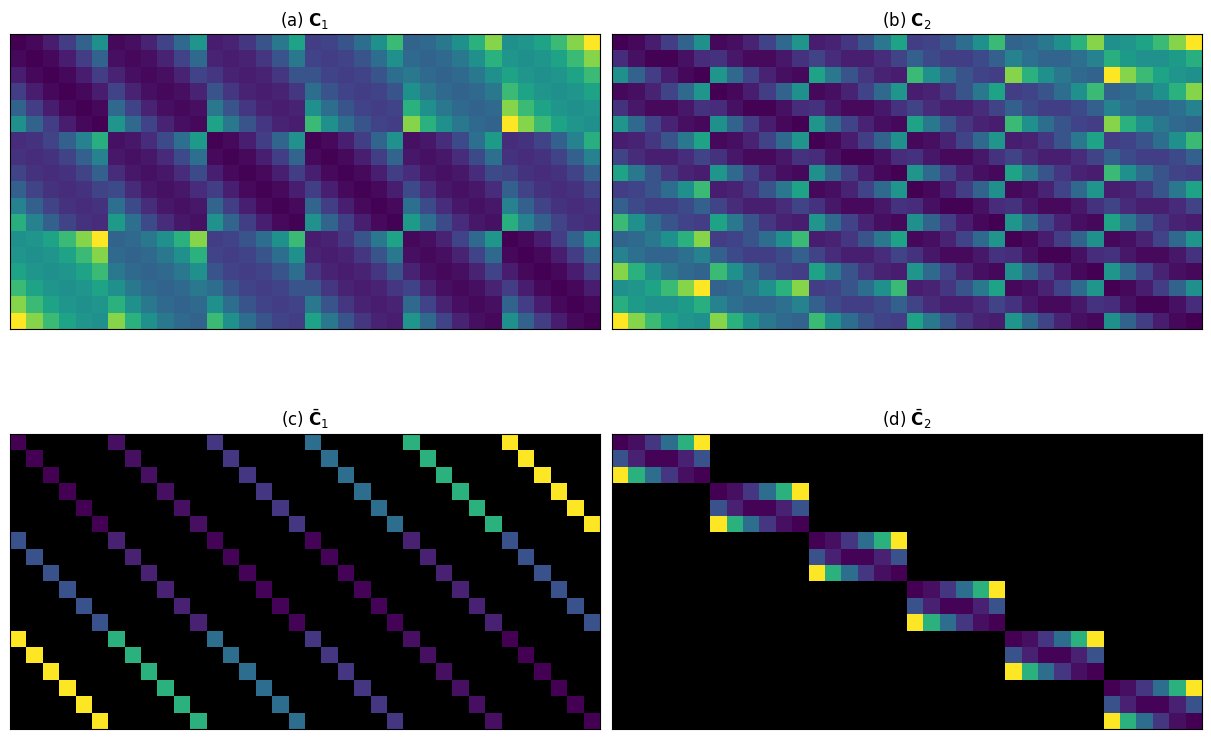

In [23]:
# Re-create supports from previous image

f_bins_1   = np.linspace(0, 1000, 6)
f_bins_2   = np.linspace(0, 1000, 3)

t_frames_1 = np.linspace(0, 1, 3)
t_frames_2 = np.linspace(0, 1, 6)

S1 = time_freq_support(f_bins_1, t_frames_1, norm=True) # we activate the norm option to compute cost matrices
S2 = time_freq_support(f_bins_2, t_frames_2, norm=True) # this allows for comparison between time (seconds) and frequency (Hz)
S  = time_freq_support(f_bins_1, t_frames_2, norm=True)

C1 = sq_cost_matrix(S1, S)
C2 = sq_cost_matrix(S2, S)
C1_bar = cost_matrix_horizontal(S1, S)
C2_bar = cost_matrix_vertical(S2, S)

axes = new_axes(2, 2)
display_cost_matrix(C1, ax=axes[0, 0], title=r'(a) $\mathbf{C}_1$')
display_cost_matrix(C2, ax=axes[0, 1], title=r'(b) $\mathbf{C}_2$')
display_cost_matrix(C1_bar, ax=axes[1, 0], title=r'(c) $\bar{\mathbf{C}}_1$')
display_cost_matrix(C2_bar, ax=axes[1, 1], title=r'(d) $\bar{\mathbf{C}}_2$')


## Fig. 4 - Initial results

### Load signal and spectrograms

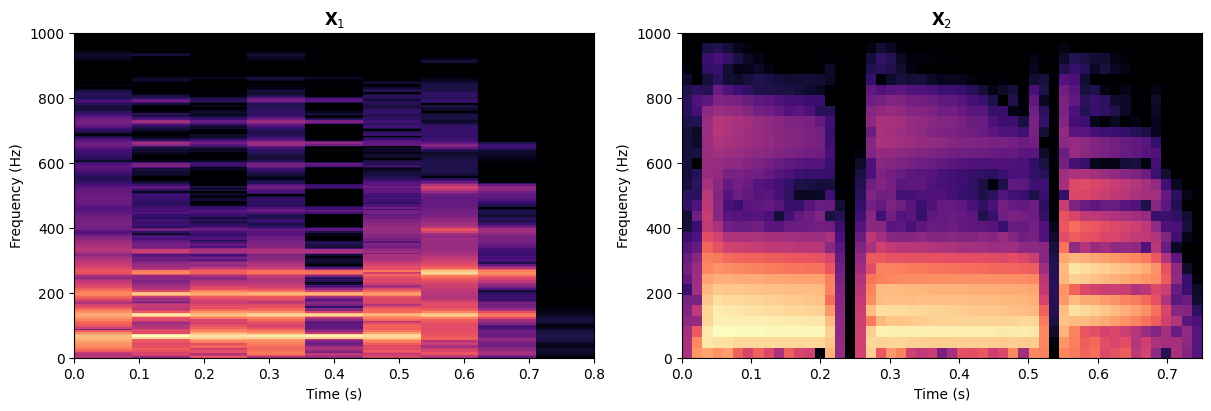

In [5]:
sr = 2000 # setting sr low to run OT (might need to reduce this further if OT doesn't work)
signal, _ = librosa.load('example_sounds/bass_notes.wav', sr=sr) 

X1 = Spectrogram(signal, sr=sr, window_size_s=200e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=30e-3)
x1 = X1.power_spectrogram()
x1 /= x1.sum() # normalization required for OT
x2 = X2.power_spectrogram()
x2 /= x2.sum() # normalization required for OT

axes = new_axes(1, 2)

display_spectrogram(x1, ax=axes[0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_1$")
display_spectrogram(x2, ax=axes[1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_2$")

### Squared Euclidean OT

Compute cost matrices for OT

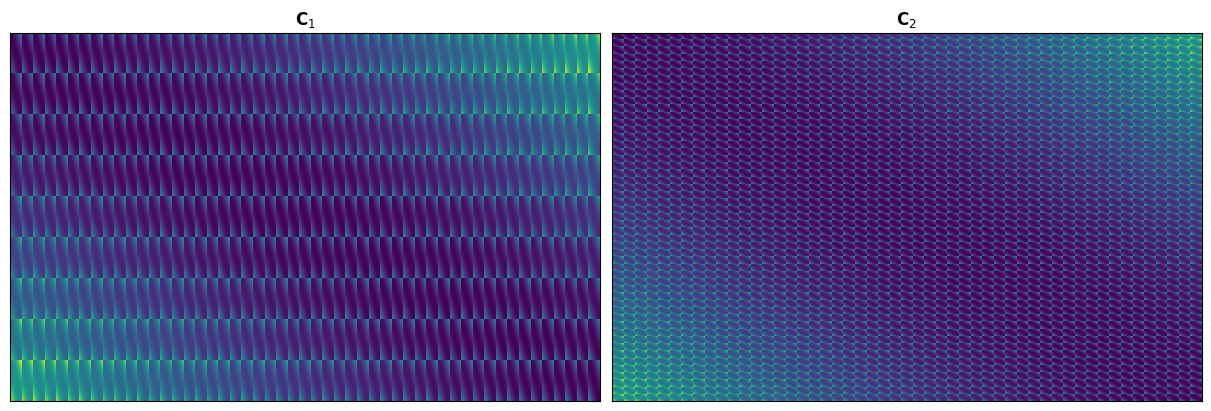

In [6]:
S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True) # High-frequency spectrogram grid
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True) # High-temporal spectrogram grid
S  = time_freq_support(X1.f_bins, X2.t_frames, norm=True) # High-resolution spectrogram grid

C1 = sq_cost_matrix(S1, S)
C2 = sq_cost_matrix(S2, S)

axes = new_axes(1, 2)
display_cost_matrix(C1, ax=axes[0], title=r'$\mathbf{C}_1$', fit=True)
display_cost_matrix(C2, ax=axes[1], title=r'$\mathbf{C}_2$', fit=True)

Compute OT barycenter

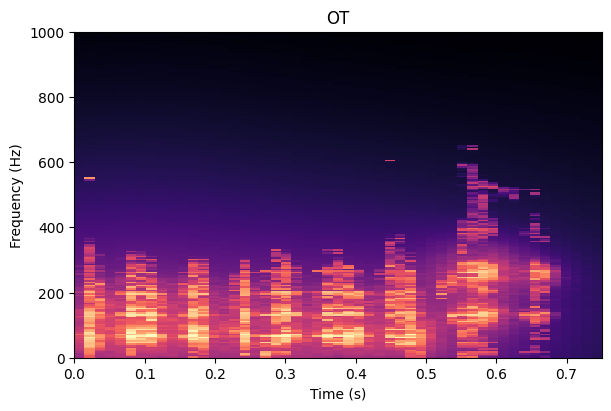

In [7]:
# take x.T.flatten() so that weights are vectorized in a column-wise fashion.

# UNCOMMENT THE FOLLOWING LINES TO COMPUTE THE OT BARYCENTER
# TAKES A LONG TIME (for 1000 iterations)
# x_OT, loss_OT, diff_OT = ot_barycenter(x1.T.flatten(), x2.T.flatten(), C1, C2, nItermax=1000, thr=0, return_diff=True, return_loss=True, verbose=True)
# x_OT = x_OT.reshape(X2.t, X1.f).T
# np.save('data/ot_barycenter.npy', x_OT)
# np.save('data/ot_loss.npy', loss_OT)
# np.save('data/ot_diff.npy', diff_OT)

# LOAD THE OT BARYCENTER DIRECTLY
x_OT = np.load('data/ot_barycenter.npy')

display_spectrogram(x_OT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='OT')

### Structured cost matrices + UOT

Compute overlap cost matrices

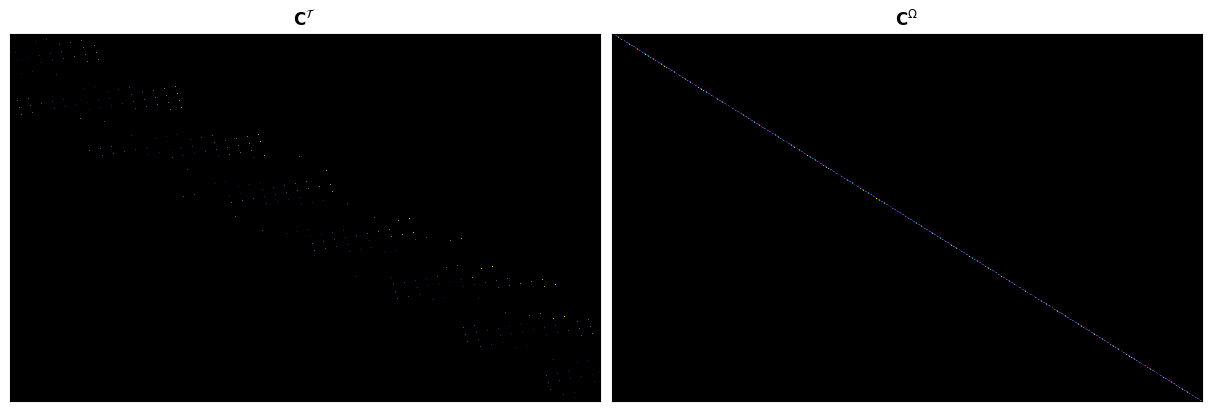

In [8]:
c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

C1_overlap = np.empty_like(C1)
C1_overlap.fill(np.nan)
C2_overlap = np.empty_like(C2)
C2_overlap.fill(np.nan)

C1_overlap[rows1, cols1] = c1
C2_overlap[rows2, cols2] = c2

axes = new_axes(1, 2)
display_cost_matrix(C1_overlap, fit=True, ax=axes[0], title=r'$\mathbf{C}^\mathcal{T}$')
display_cost_matrix(C2_overlap, fit=True, ax=axes[1], title=r'$\mathbf{C}^\Omega$')

In [9]:
# How many finite values?

C1_finite_values = C1_overlap[~np.isnan(C1_overlap)].size
C2_finite_values = C2_overlap[~np.isnan(C2_overlap)].size

print(f"C1 overlap has {C1_finite_values} finite values i.e. {100 * C1_finite_values / C1_overlap.size:.2f}% of total values.")
print(f"C2 overlap has {C2_finite_values} finite values i.e. {100 * C2_finite_values / C2_overlap.size:.2f}% of total values.")


C1 overlap has 23718 finite values i.e. 0.13% of total values.
C2 overlap has 46818 finite values i.e. 0.29% of total values.


Compute UOT barycenter

/Users/davidv/david/code/papers/fusion-ot/src/display.py:103: RuntimeWarning: divide by zero encountered in log10
  spec = 10 * np.log10(spec)


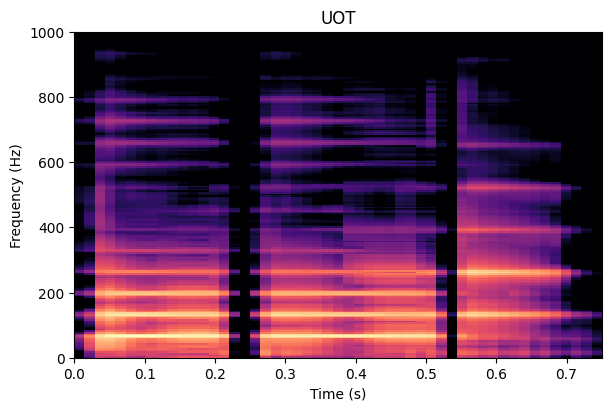

In [10]:
# take x.T.flatten() to vectorize (flatten) in a column-wise fashion (transpose)

x_UOT, loss_UOT, diff_UOT = uot_barycenter(x1.T.flatten(), 
                                           x2.T.flatten(), 
                                           c1, 
                                           c2, 
                                           rows1,
                                           cols1,
                                           rows2,
                                           cols2,
                                           eta=5,
                                           bary_size=X1.f_bins.size * X2.t_frames.size,
                                           nItermax=1000,
                                           verbose=False,
                                           return_loss=True,
                                           return_diff=True,
                                           thr=1e-5)

x_UOT = x_UOT.reshape(X2.t, X1.f).T # reshape vector to spectrogram shape

display_spectrogram(x_UOT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='UOT')

### Display 4 spectrograms

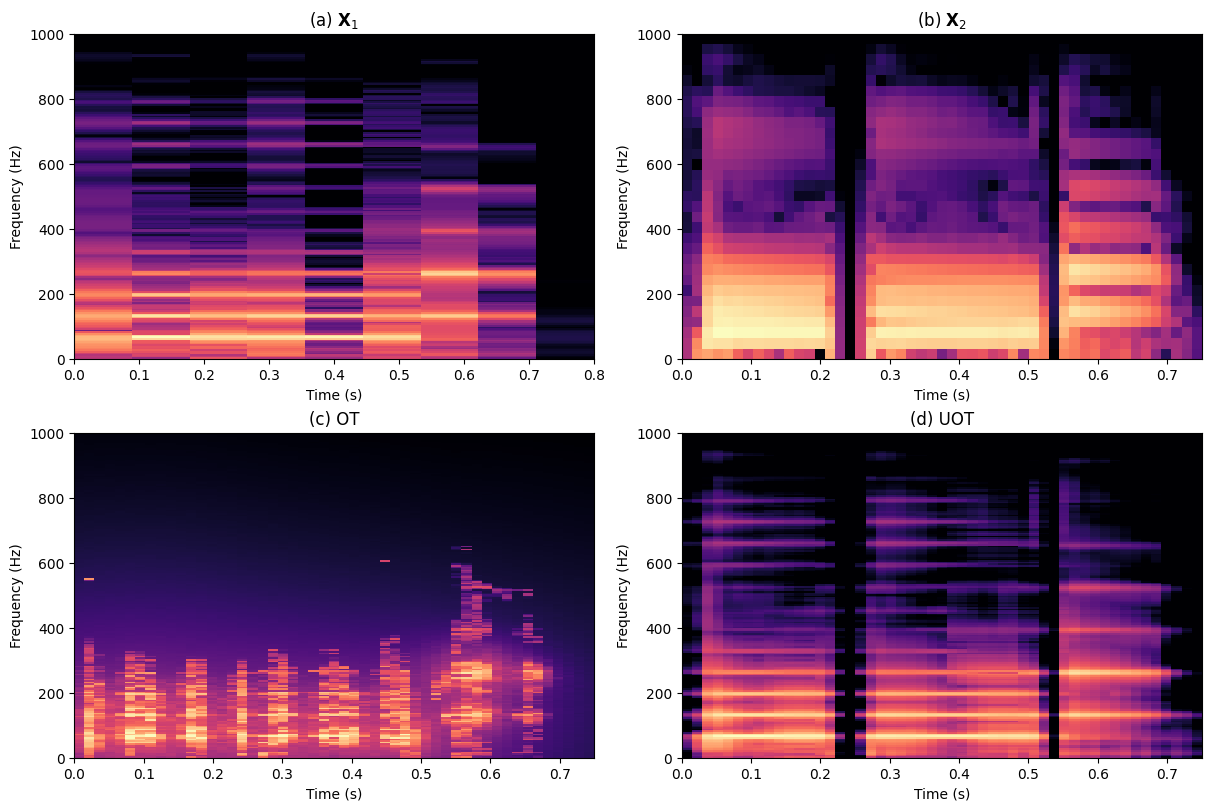

In [11]:
axes = new_axes(2, 2)

display_spectrogram(x1   , ax=axes[0, 0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"(a) $\mathbf{X}_1$")
display_spectrogram(x2   , ax=axes[0, 1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"(b) $\mathbf{X}_2$")
display_spectrogram(x_OT , ax=axes[1, 0], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(c) OT')
display_spectrogram(x_UOT, ax=axes[1, 1], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(d) UOT')


## Fig. 5 - Temporal windowing

Text(0.5, 0, 'Time')

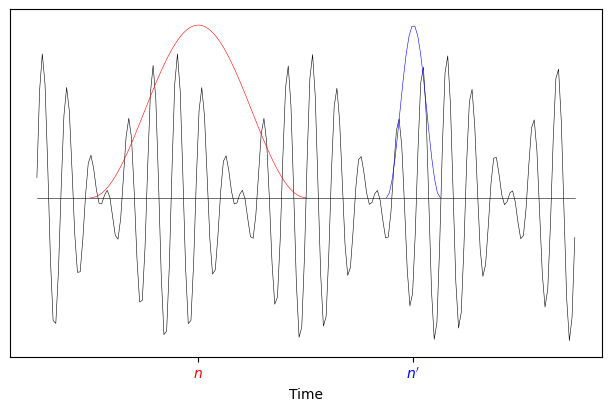

In [12]:
sr = 1000
t, signal = generate_toy_signal(sr=sr)

X1 = Spectrogram(signal, sr=sr, window_size_s=80e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3)

window_1 = X1.window.copy()
window_2 = X2.window.copy()

n_1 = 4  # index n 
n_2 = 24 # index n'

W1, W2 = X1.window_size, X2.window_size
H1, H2 = X1.hop_size, X2.hop_size

# truncate signal between 0.1 and 0.3 seconds
t_s, t_e = 0.10, 0.30
s_s, s_e = int(t_s * sr), int(t_e * sr)
t = np.linspace(t_s, t_e, s_e - s_s)
signal = signal[s_s:s_e]

# define windows' supports (see eq. 47)
t_s1, t_e1 = (n_1 * H1 - W1 / 2) / sr, (n_1 * H1 + W1 / 2) / sr
t_s2, t_e2 = (n_2 * H2 - W2 / 2) / sr, (n_2 * H2 + W2 / 2) / sr
T1 = np.linspace(t_s1, t_e1 , W1) # support of window 1
T2 = np.linspace(t_s2, t_e2 , W2) # support of window 2

# for better visualization
window_1 *= 1.2 * signal.max()
window_2 *= 1.2 * signal.max()

# timestamp of indexes n1 and n2
h_t1, h_t2 = (n_1 * H1) / sr, (n_2 * H2) / sr

ax = new_axes()
plot_signal(signal, ax=ax, times=t)
ax.plot(T1, window_1, c='red', linewidth=.4, label=r'$W_1$')
ax.plot(T2, window_2, c='blue', linewidth=.4, label=r'$W_2$')
ax.plot(t, np.zeros_like(t), c='black', linewidth=.4) # plot line at origin

# add ticks for n and n'
ax.set_xticks([h_t1, h_t2])
ax.set_xticklabels([r"$n$", r"$n'$"])
labs = ax.get_xticklabels()
labs[0].set_color('red')
labs[1].set_color('blue')

# other
ax.set_yticks([])
ax.set_xlabel('Time')


## Figs. 6 and 7 - Comparison with geometric mean

Compute geometric mean and UOT on toy signal of Fig. 1

In [13]:
sr = 1000
t, signal = generate_toy_signal(sr=sr)

X1 = Spectrogram(signal, sr=sr, window_size_s=180e-3, hop_size_s=5e-3, nfft=1024)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3, hop_size_s=5e-3, nfft=1024)

x1 = X1.power_spectrogram()
x2 = X2.power_spectrogram()

# Truncate last frames of x1
x1 = x1[:, :X2.t] # X2.t is the number of frames in x2
X1.t_frames = X1.t_frames[:X2.t]

# Geometric mean
x_geom = (x1 * x2)**.5

# UOT
S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True) # High-frequency spectrogram grid
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True) # High-temporal spectrogram grid
S  = time_freq_support(X1.f_bins, X2.t_frames, norm=True) # High-resolution spectrogram grid


c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

print("Computing UOT...", end=' ')
x_uot, loss, diff = uot_barycenter(x1.T.flatten(), 
                                   x2.T.flatten(), 
                                   c1, 
                                   c2, 
                                   rows1,
                                   cols1,
                                   rows2,
                                   cols2,
                                   eta=10,
                                   bary_size=x1.shape[0] * x2.shape[1],
                                   nItermax=500,
                                   verbose=True,
                                   return_loss=True,
                                   return_diff=True,
                                   thr=1e-5)

x_uot = x_uot.reshape(X2.t, X1.f).T


Computing UOT... Convergence attained after 257 iterations.


Display Figs. 6 and 7.

Text(0.5, 1.0, '7(b)')

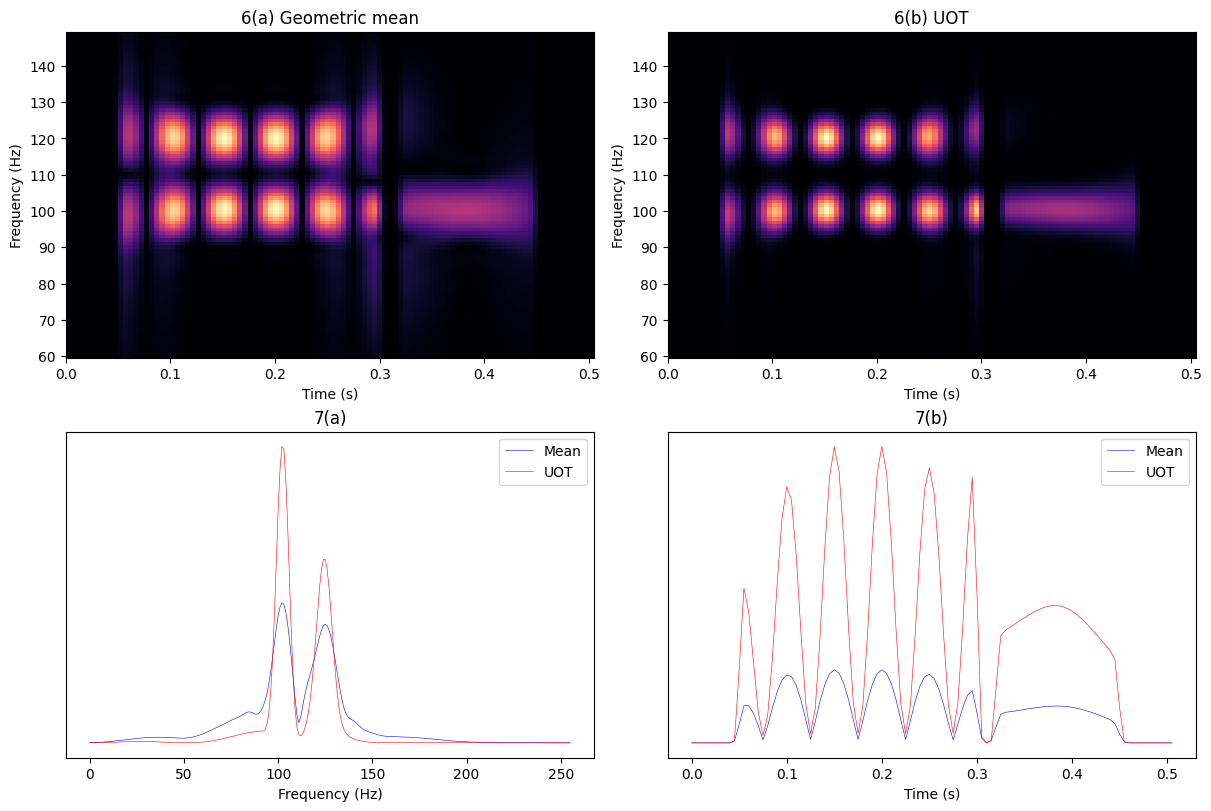

In [14]:
axes = new_axes(2, 2)

# Spectrograms
display_spectrogram(x_geom, ax=axes[0, 0], f_bins=X1.f_bins, t_frames=X2.t_frames, high_f=150, low_f=60, title='6(a) Geometric mean')
display_spectrogram(x_uot , ax=axes[0, 1], f_bins=X1.f_bins, t_frames=X2.t_frames, high_f=150, low_f=60, title='6(b) UOT')

# 1D Slices

f_slice = 100  # slice at 100Hz
t_slice = 0.28 # slice at .28 seconds

f_idx, t_idx = idx_at_value(f_slice, X1.f_bins), idx_at_value(t_slice, X2.t_frames)

max_f = 250
max_idx = idx_at_value(max_f, X1.f_bins)
axes[1, 0].plot(x_geom[:max_idx, t_idx], c='blue', label='Mean', linewidth=.4)
axes[1, 0].plot(x_uot[:max_idx, t_idx], c='red', label='UOT', linewidth=.4)
axes[1, 0].set_yticks([])
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].legend()
axes[1, 0].set_title("7(a)")

axes[1, 1].plot(X2.t_frames, x_geom[f_idx, :], c='blue', label='Mean', linewidth=.4)
axes[1, 1].plot(X2.t_frames, x_uot[f_idx, :], c='red', label='UOT', linewidth=.4)
axes[1, 1].set_yticks([])
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].set_title("7(b)")

## Figs. 8 and 9 - Same-grid vs different-grid setting

Load signal and compute spectrograms

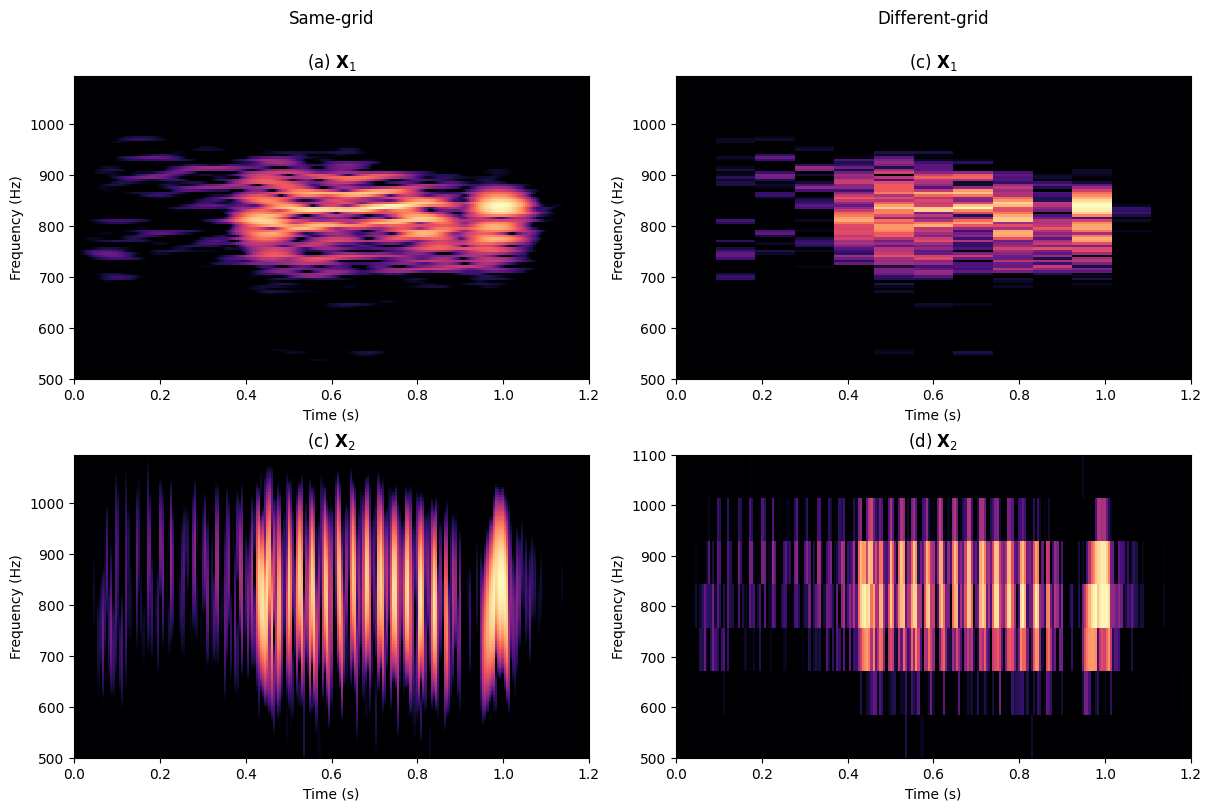

In [15]:
import librosa

sr = 16000
signal, _ = librosa.load('example_sounds/ring_necked_dove.wav', sr=sr) 

# same grid

X1_sg = Spectrogram(signal, sr=sr, window_size_s=200e-3, hop_size_s=5e-3)
X2_sg = Spectrogram(signal, sr=sr, window_size_s=10e-3, hop_size_s=5e-3, nfft=X1_sg.nfft)
x1_sg = X1_sg.power_spectrogram()
x2_sg = X2_sg.power_spectrogram()

x1_sg = x1_sg[:, :X2_sg.t]
X1_sg.t_frames = X1_sg.t_frames[:X2_sg.t]

# different grid

X1_dg = Spectrogram(signal, sr=sr, window_size_s=200e-3) # take default parameters 50% overlap, nfft = window_size / 2
X2_dg = Spectrogram(signal, sr=sr, window_size_s=10e-3)
x1_dg = X1_dg.power_spectrogram()
x2_dg = X2_dg.power_spectrogram()

axes = new_axes(2, 2)

display_spectrogram(x1_sg, ax=axes[0, 0], f_bins=X1_sg.f_bins, t_frames=X1_sg.t_frames, low_f=500, high_f=1100, log=True, logmin=-30, title="Same-grid" +  "\n\n" + r"(a) $\mathbf{X}_1$")
display_spectrogram(x1_dg, ax=axes[0, 1], f_bins=X1_dg.f_bins, t_frames=X1_dg.t_frames, low_f=500, high_f=1100, log=True, logmin=-30, title="Different-grid" +  "\n\n" + r"(c) $\mathbf{X}_1$")
display_spectrogram(x2_sg, ax=axes[1, 0], f_bins=X2_sg.f_bins, t_frames=X2_sg.t_frames, low_f=500, high_f=1100, log=True, logmin=-30, title=r"(c) $\mathbf{X}_2$")
display_spectrogram(x2_dg, ax=axes[1, 1], f_bins=X2_dg.f_bins, t_frames=X2_dg.t_frames, low_f=500, high_f=1200, log=True, logmin=-30, title=r"(d) $\mathbf{X}_2$")


Compute barycenters

In [16]:
# Same grid

S = time_freq_support(X1_sg.f_bins, X2_sg.t_frames, norm=True)
c1, rows1, cols1 = cost_matrix_horizontal_overlap(S, S, X1_sg.window_size, X2_sg.window_size, X1_sg.hop_size, X2_sg.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S, S, X1_sg.window_size, X2_sg.window_size)

print("Computing same-grid UOT...", end=' ')
start = time()
x_sg, loss, diff = uot_barycenter(x1_sg.T.flatten(), 
                                  x2_sg.T.flatten(), 
                                  c1, 
                                  c2, 
                                  rows1,
                                  cols1,
                                  rows2,
                                  cols2,
                                  eta=1,
                                  bary_size=x1_sg.shape[0] * x2_sg.shape[1],
                                  nItermax=500,
                                  verbose=True,
                                  return_loss=True,
                                  return_diff=True,
                                  thr=1e-5)
time_sg = time() - start
print(f"Took {time_sg:.2f} seconds.\n")
x_sg = x_sg.reshape(X2_sg.t, X1_sg.f).T

# Different grid

S1 = time_freq_support(X1_dg.f_bins, X1_dg.t_frames, norm=True)
S2 = time_freq_support(X2_dg.f_bins, X2_dg.t_frames, norm=True)
S  = time_freq_support(X1_dg.f_bins, X2_dg.t_frames, norm=True)

c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1_dg.window_size, X2_dg.window_size, X1_dg.hop_size, X2_dg.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1_dg.window_size, X2_dg.window_size)

print("Computing different-grid UOT...", end=' ')
start = time()
x_dg, loss, diff = uot_barycenter(x1_dg.T.flatten(), 
                                  x2_dg.T.flatten(), 
                                  c1, 
                                  c2, 
                                  rows1,
                                  cols1,
                                  rows2,
                                  cols2,
                                  eta=1,
                                  bary_size=x1_dg.shape[0] * x2_dg.shape[1],
                                  nItermax=500,
                                  verbose=True,
                                  return_loss=True,
                                  return_diff=True,
                                  thr=1e-5)
time_dg = time() - start
print(f"Took {time_dg:.2f} seconds.\n")

x_dg = x_dg.reshape(X2_dg.t, X1_dg.f).T


Computing same-grid UOT... Convergence attained after 248 iterations.
Took 152.04 seconds.

Computing different-grid UOT... Convergence attained after 105 iterations.
Took 3.61 seconds.



Display barycenters

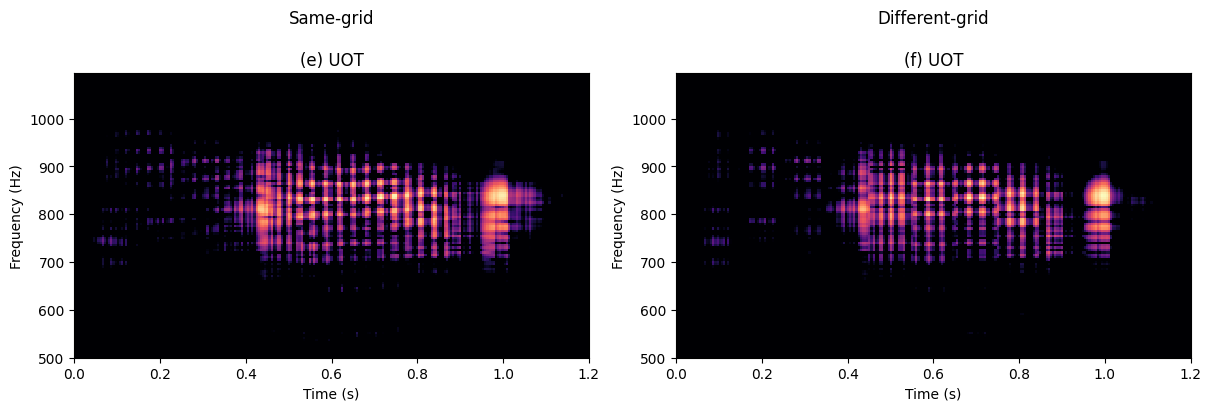

In [17]:
axes = new_axes(1, 2)

display_spectrogram(x_sg, ax=axes[0], f_bins=X1_sg.f_bins, t_frames=X2_sg.t_frames, low_f=500, high_f=1100, log=True, logmin=-30, title=r"Same-grid" +  "\n\n" + r"(e) UOT")
display_spectrogram(x_dg, ax=axes[1], f_bins=X1_dg.f_bins, t_frames=X2_dg.t_frames, low_f=500, high_f=1100, log=True, logmin=-30, title=r"Different-grid" +  "\n\n" + r"(f) UOT")

## Figs. 10 and 11 - Target mel-frequency axis support

Fig. 10 - Mel support

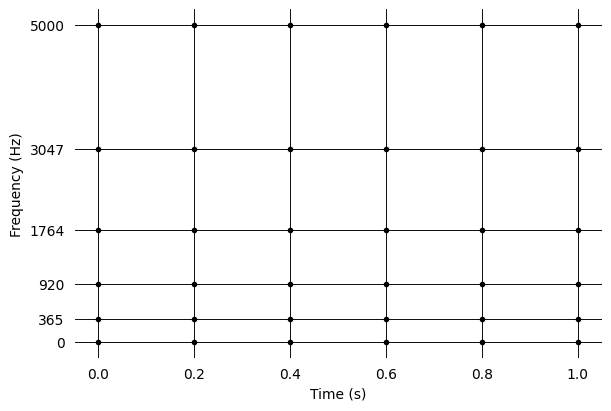

In [18]:
sr = 10000

m_bins = mel_frequency_bins(6, sr)
t_frames   = np.linspace(0, 1, 6)

S_mel = time_freq_support(m_bins, t_frames, norm=False)

display_support(S_mel)

We first compute a barycenter directly on the mel scale between $\mathbf{X}_1$ and $\mathbf{X}_2$. We compare it with:

* Mel spectrogram of $\mathbf{X}_1$ computed using traditional pipeline.
* Mel spectrogram of $\mathbf{X}_2$ computed using traditional pipeline.
* 2-step super resolution mel: (i) compute super-resolution between $\mathbf{X}_1$ and $\mathbf{X}_2$ (ii) compute mel using traditional pipeline


Convergence attained after 268 iterations.
Convergence attained after 147 iterations.


/Users/davidv/david/code/papers/fusion-ot/.venv/lib/python3.14/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/Users/davidv/david/code/papers/fusion-ot/src/display.py:103: RuntimeWarning: divide by zero encountered in log10
  spec = 10 * np.log10(spec)


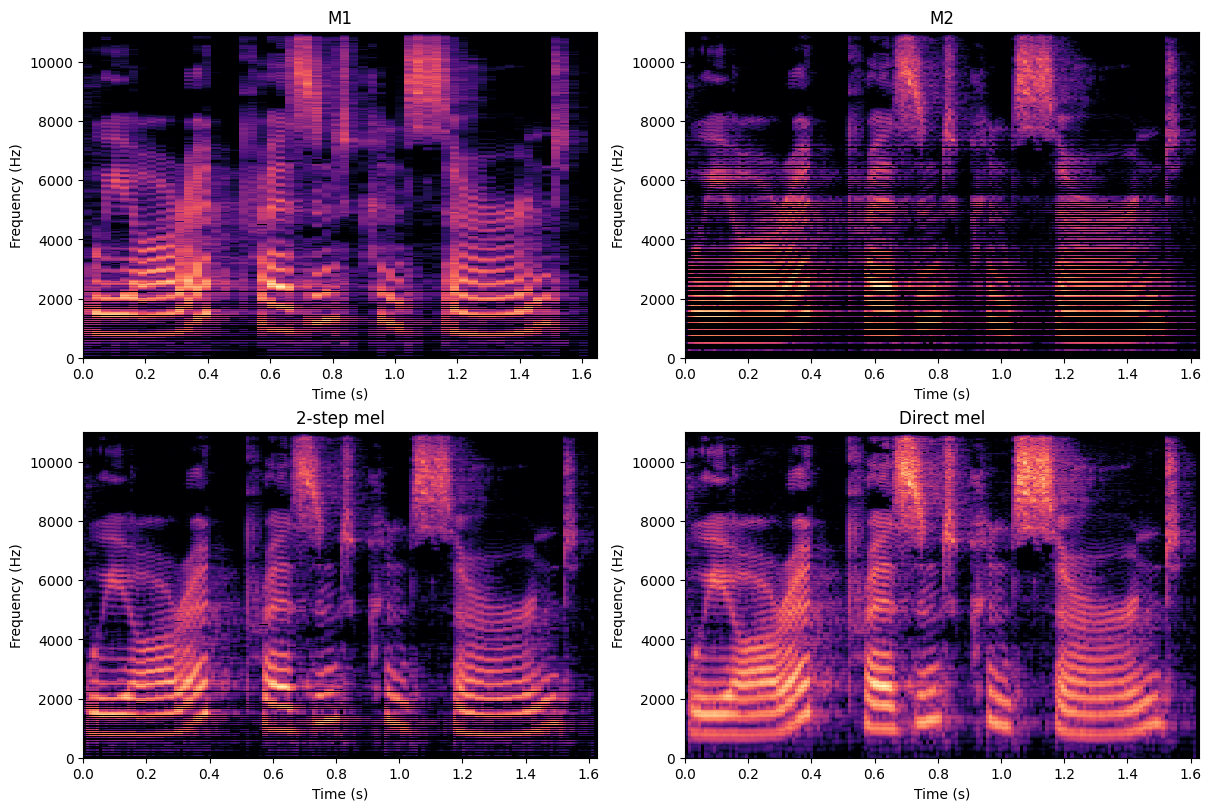

In [19]:
sr = 22050
signal, _ = librosa.load('example_sounds/woman_speech.wav', sr=sr)

X1 = Spectrogram(signal, sr, 60e-3)
X2 = Spectrogram(signal, sr, 20e-3)

x1 = X1.power_spectrogram()
x2 = X2.power_spectrogram()

n_bins = 500
m_bins_1 = mel_frequency_bins(n_bins, sr)

S1 = time_freq_support(X1.f_bins, X1.t_frames)
S2 = time_freq_support(X2.f_bins, X2.t_frames)

# direct mel

S_mel  = time_freq_support(m_bins_1, X2.t_frames)
c1, rows1, cols1 = cost_matrix_horizontal_overlap_mel(S1, S_mel, X1.window_size, X2.window_size, sr, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap_mel(S2, S_mel, X1.window_size, X2.window_size, sr)

c1 /= c1.max()
c2 /= c2.max()

thr = 1e-5

x_mel = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=.5,
                       bary_size= m_bins_1.size * X2.t,
                       nItermax=500,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=1e-5)

x_mel = x_mel.reshape(X2.t, m_bins_1.size).T

# 2-step mel

S = time_freq_support(X1.f_bins, X2.t_frames)

c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

x_uot = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=1,
                       bary_size=x1.shape[0] * x2.shape[1],
                       nItermax=500,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=1e-5)


x_uot = x_uot.reshape(X2.t, X1.f).T
x_uot_mel = librosa.feature.melspectrogram(S=x_uot, n_mels=n_bins, htk=True)

# Mel spectrograms of X1 and X2

m1 = librosa.feature.melspectrogram(S=x1, n_mels=n_bins, htk=True)
m2 = librosa.feature.melspectrogram(S=x2, n_mels=n_bins, htk=True)

axes = new_axes(2, 2)
display_spectrogram(m1, ax=axes[0, 0], title='M1', f_bins=m_bins_1, t_frames=X1.t_frames, log=True)
display_spectrogram(m2, ax=axes[0, 1], title='M2', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(x_uot_mel, ax=axes[1, 0], title='2-step mel', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(x_mel, ax=axes[1, 1], title='Direct mel', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)

Fig. 11 - Compare super-resolution mel with another mel

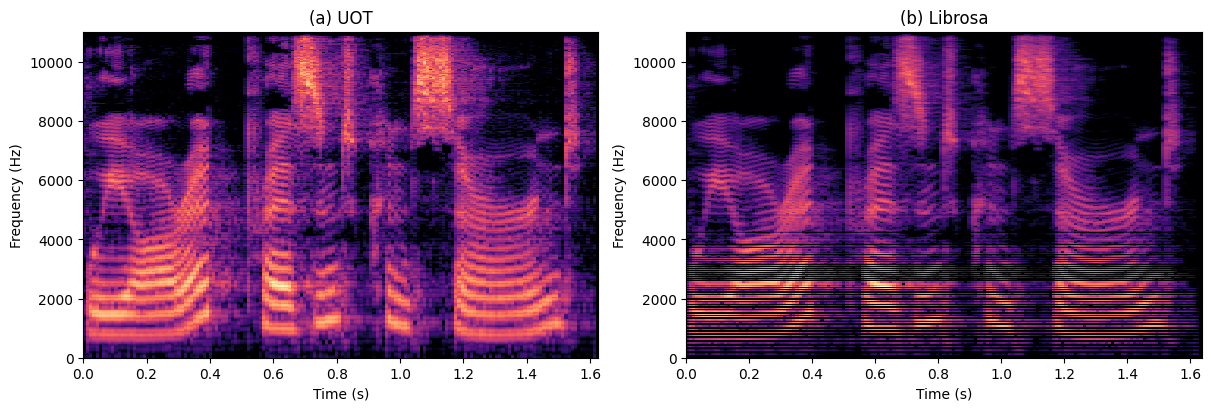

In [20]:
# Other spectrogram to compare with

X3 = Spectrogram(signal, sr, window_size_s=40e-3, hop_size_s=X2.hop_size_s)
m3 = librosa.feature.melspectrogram(S=X3.power_spectrogram(), n_mels=x_mel.shape[0], htk=True)

axes = new_axes(1, 2)
display_spectrogram(x_mel, ax=axes[0], title='(a) UOT', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(m3, ax=axes[1], title='(b) Librosa', f_bins=m_bins_1, t_frames=X3.t_frames, log=True)

## Fig 12 - Fourier transform of Hann window

(-200.0, 200.0)

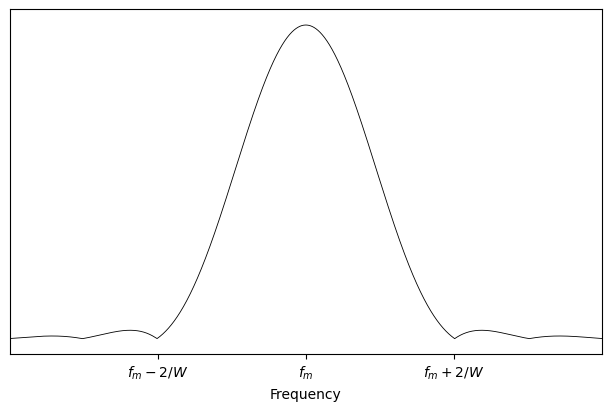

In [21]:
sr = 8000
window_size_seconds = 20e-3

window = hann(int(sr * window_size_seconds))
window_ft = np.fft.fft(window, n=100000)
window_ft = np.abs(window_ft)
freqs = np.fft.fftfreq(window_ft.size, d=1/sr)

window_ft = np.fft.fftshift(window_ft) # center at f=0Hz.
freqs = np.fft.fftshift(freqs)

axes = new_axes()
axes.set_yticks([])
axes.plot(freqs, window_ft, c='black', linewidth=.6)
axes.set_xlabel("Frequency")
axes.set_xticks([-2 / window_size_seconds, 0,  2 / window_size_seconds])
axes.set_xticklabels([r"$f_m -2 / W$", r"$f_m$", r"$f_m +2 / W$"]);
axes.set_xlim(-200, 200)